In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.model_pipeline import ModelPipeline

In [2]:
df_final = pd.read_parquet("data/feature_engineering/credit/v3/df_credit_final.parquet")
df_final = df_final.set_index("Transaction Serial No", drop=True)

# Box-Plot Numerical Importance Features

In [3]:
split_date = "2025-05-01"

In [4]:
# setup pipeline
pipeline = ModelPipeline(model_type="random_forest", random_state=42)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest


In [5]:
df_splits = pipeline.split_data_by_date(
    df=df_final, date_column="Transaction Datetime", split_date=split_date
)

Splitting data by date (pre-preprocessing)...
Train samples: 1197282, Test samples: 201546
Data splitting complete.


In [7]:
# prepare data
target_col = "Confirmed"
X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=False,
    is_apply_log=False,
    is_impute_median=True,
    is_training=True,
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
  Mapping Y/N to 1/0 in column: IsBlacklistCust
  Mapping Y/N to 1/0 in column: IsHighRiskCountry
  Mapping Y/N to 1/0 in column: IsBlacklistMerchant
  Mapping Y/N to 1/0 in column: IsWatchListMerchant
  Mapping Y/N to 1/0 in column: IsHighRiskMCC
  Mapping Y/N to 1/0 in column: IsBlacklistCardNo
  Mapping Y/N to 1/0 in column: IsValidCard
  Mapping Y/N to 1/0 in column: Is3DSecure
  Mapping Y/N to 1/0 in column: IsWhiteListMerchant
  Mapping Y/N to 1/0 in column: IsBDIEmail
  Mapping Y/N to 1/0 in column: IsWhiteListCardNo
  Mapping Y/N to 1/0 in column: IsWhitelistCardNoOpen
  Mapping Y/N to 1/0 in column: IsWatchlistCardNo
  Mapping Y/N to 1/0 in column: IsBlackListTID
  Mapping Y/N to 1/0 in column: IsFirstTrx3DS
  Mapping Y/N to 1/0 in column: IsHighRiskCountryThresholdAmt
  Mapping Y/N to 1/0 in column: IsHighRiskCurrency
  Mapping Y/N to 1/0 in column: IsHighRiskCurrencyThresholdAmt
  Mapping

In [8]:
# prepare data
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_test"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=False,
    is_apply_log=False,
    is_impute_median=True,
    is_training=False,
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
  Mapping Y/N to 1/0 in column: IsBlacklistCust
  Mapping Y/N to 1/0 in column: IsHighRiskCountry
  Mapping Y/N to 1/0 in column: IsBlacklistMerchant
  Mapping Y/N to 1/0 in column: IsWatchListMerchant
  Mapping Y/N to 1/0 in column: IsHighRiskMCC
  Mapping Y/N to 1/0 in column: IsBlacklistCardNo
  Mapping Y/N to 1/0 in column: IsValidCard
  Mapping Y/N to 1/0 in column: Is3DSecure
  Mapping Y/N to 1/0 in column: IsWhiteListMerchant
  Mapping Y/N to 1/0 in column: IsBDIEmail
  Mapping Y/N to 1/0 in column: IsWhiteListCardNo
  Mapping Y/N to 1/0 in column: IsWhitelistCardNoOpen
  Mapping Y/N to 1/0 in column: IsWatchlistCardNo
  Mapping Y/N to 1/0 in column: IsBlackListTID
  Mapping Y/N to 1/0 in column: IsFirstTrx3DS
  Mapping Y/N to 1/0 in column: IsHighRiskCountryThresholdAmt
  Mapping Y/N to 1/0 in column: IsHighRiskCurrency
  Mapping Y/N to 1/0 in column: IsHighRiskCurrencyThresholdAmt
  Mappin

In [9]:
df_train = X.copy()
df_train["Confirmed"] = y

## Time Difference (in Minutes)

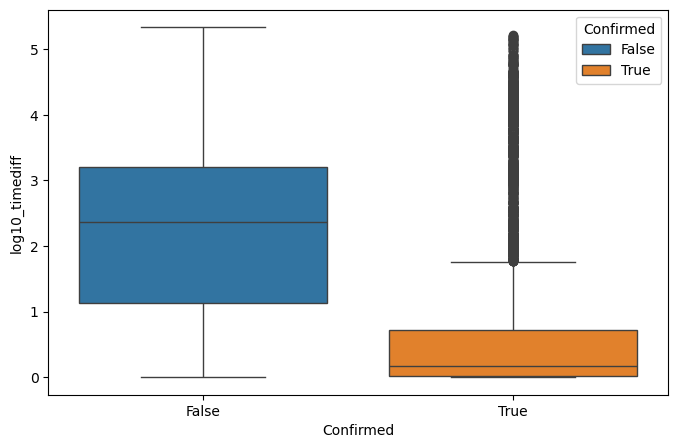

In [9]:
df_train["log10_timediff"] = np.log10(df_train["time_diff"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_timediff", hue="Confirmed", data=df_train)
plt.show()

## Transaction Amount

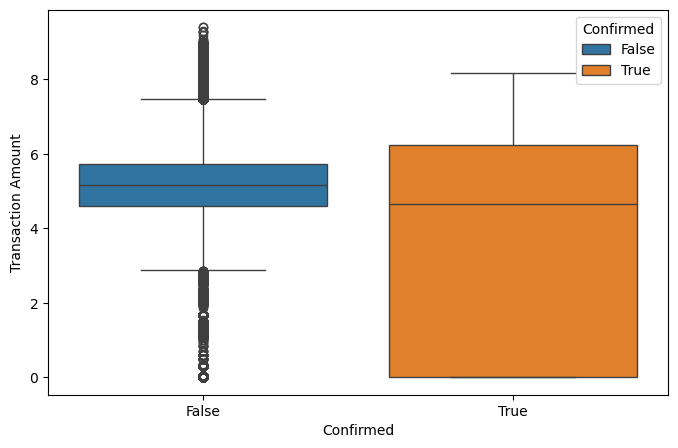

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="Transaction Amount", hue="Confirmed", data=df_train)
plt.show()

## Transaction Count Last 15m, 1H

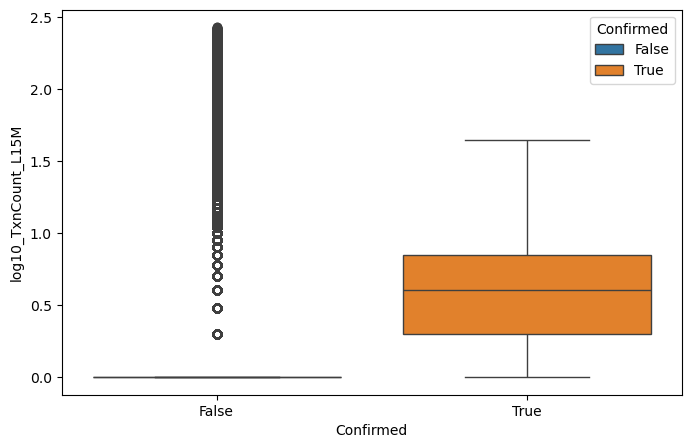

In [11]:
df_train["log10_TxnCount_L15M"] = np.log10(df_train["TxnCount_L15M"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_TxnCount_L15M", hue="Confirmed", data=df_train)
plt.show()

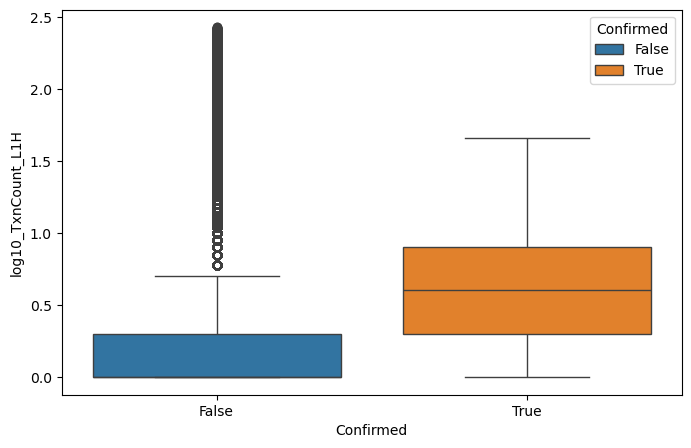

In [12]:
df_train["log10_TxnCount_L1H"] = np.log10(df_train["TxnCount_L1H"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_TxnCount_L1H", hue="Confirmed", data=df_train)
plt.show()

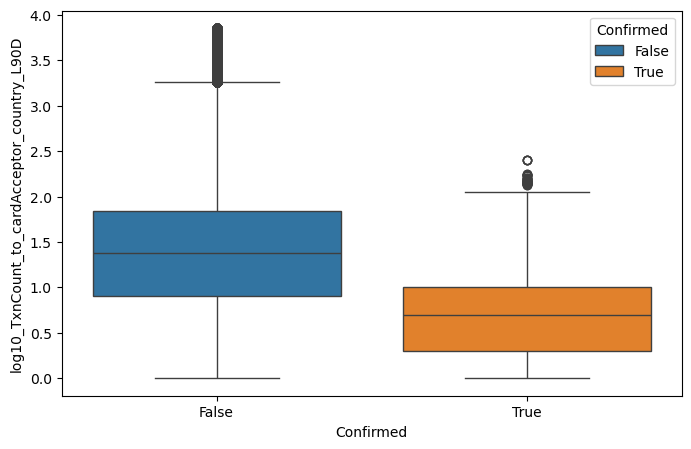

In [13]:
df_train["log10_TxnCount_to_cardAcceptor_country_L90D"] = np.log10(
    df_train["TxnCount_to_cardAcceptor_country_L90D"] + 1
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Confirmed",
    y="log10_TxnCount_to_cardAcceptor_country_L90D",
    hue="Confirmed",
    data=df_train,
)
plt.show()

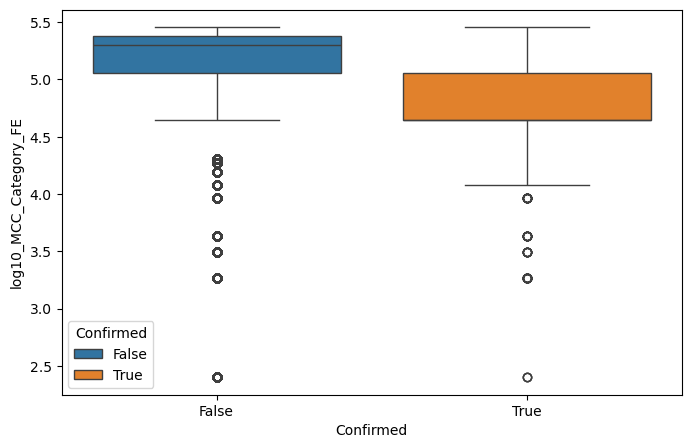

In [14]:
df_train["log10_MCC_Category_FE"] = np.log10(df_train["MCC Category_FE"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_MCC_Category_FE", hue="Confirmed", data=df_train)
plt.show()

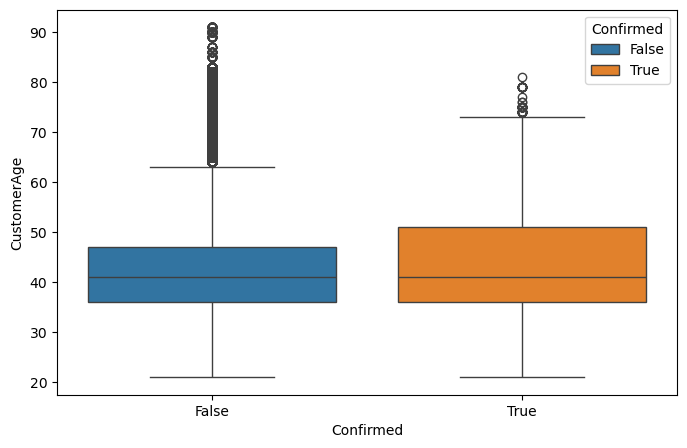

In [15]:
# df_train["log10_MCC_Category_FE"] = np.log10(df_train["MCC Category_FE"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="CustomerAge", hue="Confirmed", data=df_train)
plt.show()

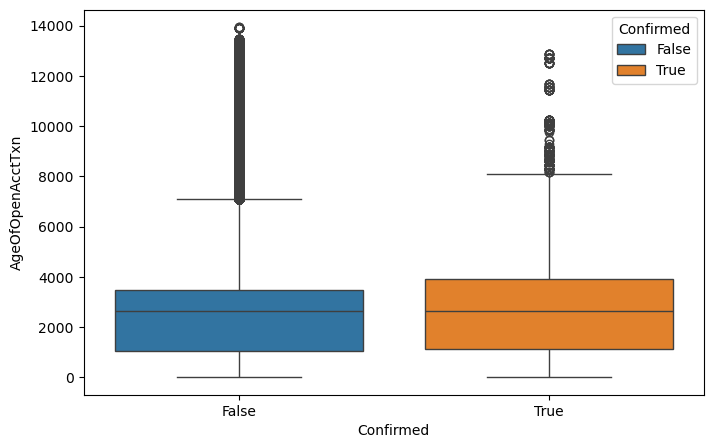

In [16]:
# df_train["log10_AgeOfOpenAcctTxn"] = np.log10(df_train["AgeOfOpenAcctTxn"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="AgeOfOpenAcctTxn", hue="Confirmed", data=df_train)
plt.show()

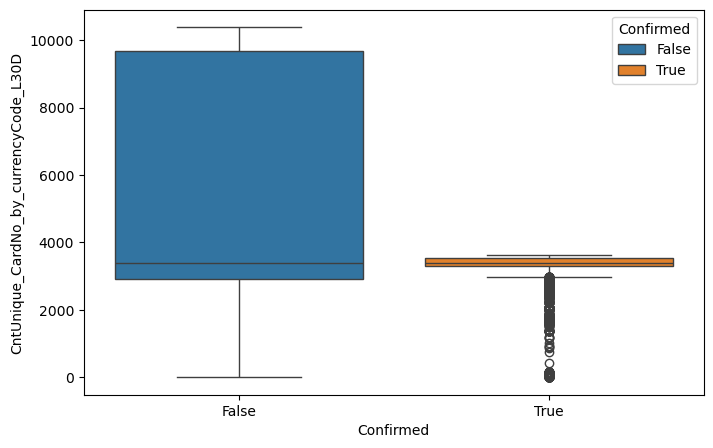

In [17]:
df_train["log10_CntUnique_CardNo_by_currencyCode_L30D"] = np.log10(
    df_train["CntUnique_CardNo_by_currencyCode_L30D"] + 1
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Confirmed",
    y="CntUnique_CardNo_by_currencyCode_L30D",
    hue="Confirmed",
    data=df_train,
)
plt.show()

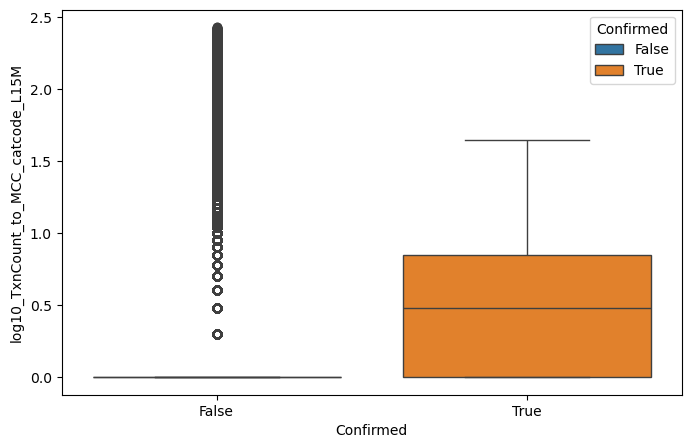

In [18]:
df_train["log10_TxnCount_to_MCC_catcode_L15M"] = np.log10(
    df_train["TxnCount_to_MCC_catcode_L15M"] + 1
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Confirmed",
    y="log10_TxnCount_to_MCC_catcode_L15M",
    hue="Confirmed",
    data=df_train,
)
plt.show()

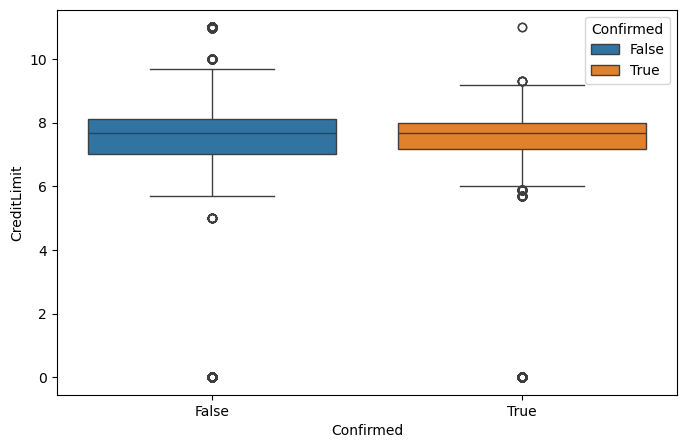

In [24]:
# df_train["log10_CreditLimit"] = np.log10(df_train["CreditLimit"] + 1)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Confirmed", y="log10_CreditLimit", hue="Confirmed", data=df_train)
plt.show()

# Gini Feature Importance, PSI, and IV

## Gini Feature Importance

In [8]:
importance_df = pd.read_csv(
    "data/result/credit_model_feature_importance_rf_20250616.csv"
)

In [9]:
feat_importance_list = importance_df[
    importance_df["importance"] > 1e-05
].feature.tolist()

In [10]:
len(feat_importance_list)

251

## PSI

In [10]:
from src.feature_stability import (
    calculate_iv_for_all_features,
    calculate_psi_for_all_features,
)

In [11]:
df_splits["df_train"] = df_splits["df_train"].drop("Transaction Datetime", axis=1)
df_splits["df_test"] = df_splits["df_test"].drop("Transaction Datetime", axis=1)

In [15]:
numerical_cols = X.select_dtypes(include=["float32", "float64"])

psi_df = calculate_psi_for_all_features(
    train_df=X, test_df=X_oos, features=numerical_cols, buckets=10
)

Calculate PSI Progress...:   0%|          | 202/1197282 [00:21<37:07:06,  8.96it/s]C:\Users\Administrator\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
Calculate PSI Progress...:   0%|          | 203/1197282 [00:21<37:31:34,  8.86it/s]C:\Users\Administrator\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
Calculate PSI Progress...:   0%|          | 204/1197282 [00:21<37:15:59,  8.92it/s]C:\Users\Administrator\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
Calculate PSI Progress...:   0%|          | 205/1197282 [00:21<36:16:32,  9.17it/s]C:\Users\Administrator\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero enco

In [11]:
# psi_df.to_csv("data/result/credit_model_feature_PSI_20250616.csv", index=False)
psi_df = pd.read_csv("data/result/credit_model_feature_PSI_20250616.csv")

In [12]:
feat_high_psi = psi_df[
    (psi_df["PSI"] > 0.2) & (~np.isinf(psi_df["PSI"]))
].Feature.tolist()

In [13]:
final_feat_yet = [col for col in feat_importance_list if col not in feat_high_psi]

In [14]:
len(final_feat_yet)

243

In [30]:
psi_df["PSI"] = np.round(psi_df["PSI"], 6)
psi_df[psi_df.Feature.isin(feat_high_psi)]

,Feature,PSI
191,CntUnique_CardNo_by_MCC_L30D,0.930839
192,CntUnique_CardNo_by_MCC_L90D,0.703743
55,TxnCount_to_cardAcceptor_country_L30D,0.408144
209,CntUnique_CardNo_by_cardAcceptor_country_L1D,0.307059
199,CntUnique_CardNo_by_cardAcceptor_cat_L90D,0.249308
56,TxnCount_to_cardAcceptor_country_L90D,0.240185
190,CntUnique_CardNo_by_MCC_L14D,0.232385
189,CntUnique_CardNo_by_MCC_L7D,0.213028


## Information Value (IV)

In [17]:
numerical_cols = X.select_dtypes(include=["float32", "float64"])

iv_df = calculate_iv_for_all_features(
    df=X.join(y), features=numerical_cols, target="Confirmed", bins=10
)

Calculate IV Progress...:   0%|          | 0/1197282 [00:00<?, ?it/s]C:\Users\Administrator\BDI-predator\ml-fraud\src\feature_stability.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")[target].agg(["count", "sum"])
Calculate IV Progress...:   0%|          | 1/1197282 [00:01<373:57:50,  1.12s/it]C:\Users\Administrator\BDI-predator\ml-fraud\src\feature_stability.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")[target].agg(["count", "sum"])
Calculate IV Progress...:   0%|          | 2/1197282 [00:02<367:59:11,  1.11s/it]C:\Users\Administrator\BDI-pr

In [16]:
# pd.set_option("display.max_rows", None)
# iv_df.to_csv("data/result/credit_model_feature_IV_20250616.csv", index=False)
iv_df = pd.read_csv("data/result/credit_model_feature_IV_20250616.csv")

In [28]:
low_iv_feats = iv_df[iv_df["IV"] < 0.2].Feature.tolist()

In [29]:
final_feats = [col for col in final_feat_yet if col not in low_iv_feats]

In [30]:
len(low_iv_feats)

69

In [27]:
low_iv_feats

['Avg_Amt_L90D',
 'TxnCount_L1D',
 'TxnCount_to_countryCode_L1D',
 'TxnCount_to_cardAcceptor_cat_L1D',
 'TxnCount_to_MCC_L1D',
 'CashCreditLimit',
 'AgeOfActiveCardTxn',
 'CntUnique_CardNo_by_currencyCode_L15M',
 'CntUnique_MCC_by_CardNo_L90D',
 'AgeOfOpenAcctTxn',
 'TxnCount_to_cardAcceptor_country_L15M',
 'TxnCount_to_cardAcceptor_country_L1D',
 'CntUnique_CardNo_by_MCC_L15M',
 'IsBucket2BlacklistMerchant',
 'TxnCount_to_MCC_cat_L7D',
 'TxnCount_to_MCC_catcode_L7D',
 'TxnCount_to_MCC_details_L7D',
 'TotalTrxAmountContactless',
 'CntUnique_MCC_by_CardNo_L30D',
 'TxnCount_to_MCC_details_L1D',
 'TxnCount_to_MCC_cat_L1D',
 'TxnCount_to_MCC_catcode_L1D',
 'NumOfTrxL1D',
 'TxnCount_L1H',
 'NumOfTrxL7D',
 'IsBlacklistMerchant',
 'TxnCount_to_cardAcceptor_cat_L1H',
 'TxnCount_to_MCC_L1H',
 'TxnCount_to_MCC_catcode_L1H',
 'TxnCount_to_MCC_cat_L1H',
 'TxnCount_to_countryCode_L1H',
 'TxnCount_L15M',
 'CntUnique_MCC_by_CardNo_L14D',
 'TxnCount_to_cardAcceptor_cat_L15M',
 'TxnCount_to_MCC_L15M',


In [31]:
len(final_feats)

194

In [32]:
final_feats

['time_diff',
 'CntUnique_CardNo_by_currencyCode_L30D',
 'CntUnique_CardNo_by_cardAcceptor_country_L30D',
 'CntUnique_CardNo_by_cardAcceptor_country_L7D',
 'CntUnique_CardNo_by_currencyCode_L14D',
 'POSMode_FE',
 'CntUnique_CardNo_by_cardAcceptor_country_L14D',
 'CntUnique_CardNo_by_currencyCode_L90D',
 'MCC Category_FE',
 'CntUnique_MCC_by_CardNo_L1H',
 'CntUnique_CardNo_by_cardAcceptor_country_L90D',
 'CntUnique_CardNo_by_currencyCode_L1D',
 'CntUnique_CardNo_by_currencyCode_L7D',
 'TransactionType_FE',
 'TxnCount_to_MCC_cat_L90D',
 'TxnCount_to_MCC_L90D',
 'Transaction Amount',
 'TxnCount_to_MCC_details_L90D',
 'TxnCount_to_cardAcceptor_cat_L90D',
 'CntUnique_MCC_by_CardNo_L15M',
 'Sum_Amt_to_cardAcceptor_country_L90D',
 'Max_Amt_to_MCC_L90D',
 'Max_Amt_to_cardAcceptor_country_L90D',
 'Sum_Amt_to_MCC_L90D',
 'CntUnique_CardNo_by_cardAcceptor_country_L1H',
 'Cat Card Acceptor Name_FE',
 'Avg_Amt_to_cardAcceptor_country_L90D',
 'CntUnique_CardNo_by_cardAcceptor_cat_L14D',
 'Avg_Amt_to

In [24]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression


def remove_correlated_features_target_aware(
    df,
    target,
    features,
    problem_type="classification",
    threshold=0.85,
    method="pearson",
    verbose=True,
):
    """
    Removes highly correlated feature while keeping the most predictive one
    based on correlation to target
    """

    df_numeric = df[features]
    corr_matrix = df_numeric.corr(method=method).abs()
    upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_corr = corr_matrix.where(upper)

    # calculate feature importance to target
    if problem_type == "classification":
        feature_scores = pd.Series(
            mutual_info_classif(df_numeric.fillna(0), target), index=df_numeric.columns
        )
    elif problem_type == "regression":
        feature_scores = pd.Series(
            mutual_info_regression(df_numeric.fillna(0), target),
            index=df_numeric.columns,
        )
    else:
        raise ValueError("problem type must be 'classification' or 'regression'")

    removed = set()

    # greedily remove less important features from each highly correlated pair
    for col in upper_corr.columns:
        for row in upper_corr.index:
            if upper_corr.loc[row, col] > threshold:
                if row in removed or col in removed:
                    continue
                score_row = feature_scores[row]
                score_col = feature_scores[col]
                if score_row >= score_col:
                    remove.add(col)
                else:
                    removed.add(row)

    if verbose:
        print(f"Removed columns: {list(removed)}")

    return list(removed)

In [28]:
high_corr_feats = remove_correlated_features_target_aware(
    df=X,
    target=y,
    features=final_feats,
    problem_type="classification",
    threshold=0.85,
)


KeyboardInterrupt



In [ ]:
high_corr_feats